In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = yf.download('^NSEBANK' , start = '2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEBANK,^NSEBANK,^NSEBANK,^NSEBANK,^NSEBANK
Date,,,,,
2024-01-01,48234.300781,48450.000000,48044.148438,48203.449219,146900
2024-01-02,47761.648438,48223.550781,47689.800781,48194.800781,183200
2024-01-03,47704.949219,47798.750000,47481.351562,47796.300781,233300
2024-01-04,48195.851562,48281.199219,47738.148438,47805.398438,175700
2024-01-05,48159.000000,48381.949219,47822.851562,48245.550781,181000


In [8]:
!pip install prophet
from prophet import Prophet

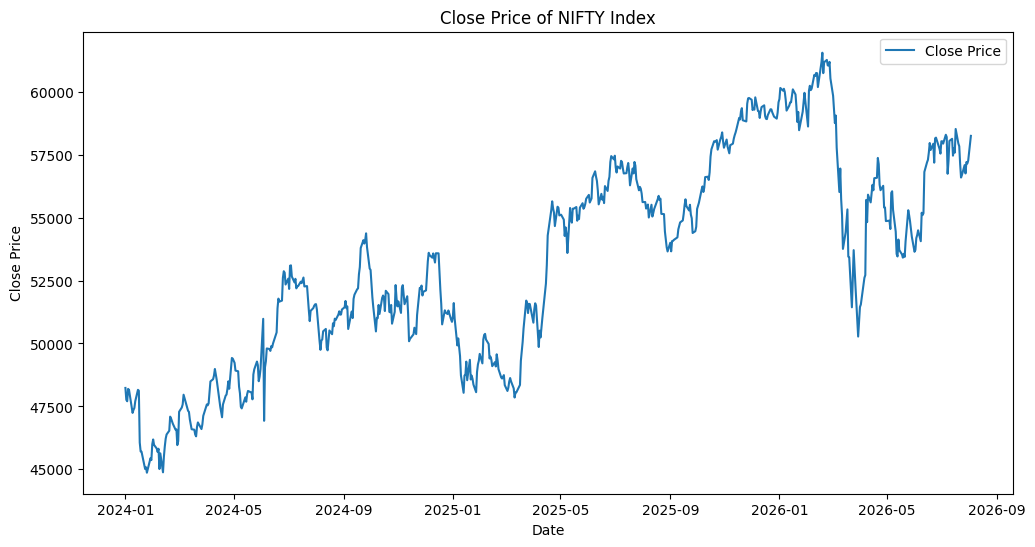

In [9]:
plt.figure(figsize = (12,6))
plt.plot(data.index , data['Close'], label = 'Close Price')
plt.title('Close Price of NIFTY Index')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [17]:
m = Prophet()
data_1 = data.reset_index()
data_1= data_1[['Date', 'Close']]
data_1.columns = ['ds', 'y']
m.fit(data_1)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [18]:
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

In [21]:
from prophet.plot import plot_plotly , plot_components_plotly

plot_plotly(m , forecast)


In [22]:
plot_components_plotly(m , forecast)